The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Self-organized criticality

In the previous chapter we saw an example of a system with a critical point and we explored one of the common properties of critical systems, fractal geometry.

In this chapter, we explore two other properties of critical systems: heavy-tailed distributions, which we saw in Chapter 4, and pink noise, which I'll explain in this chapter.

These properties are interesting in part because they appear frequently in nature; that is, many natural systems produce fractal-like geometry, heavy-tailed distributions, and pink noise.

This observation raises a natural question: why do so many natural systems have properties of critical systems? A possible answer is **self-organized criticality** (SOC), which is the tendency of some systems to evolve toward, and stay in, a critical state.

In this chapter I'll present a **sand pile model** that was the first system shown to exhibit SOC.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity/blob/v3/soln/chap08.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/utils.py')
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/Cell1D.py')
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/Cell2D.py')

In [3]:
from utils import decorate, savefig
# make a directory for figures
!mkdir -p figs

## Critical Systems

Many critical systems demonstrate common behaviors:

-   Fractal geometry: For example, freezing water tends to form fractal patterns, including snowflakes and other crystal structures. Fractals are characterized by self-similarity; that is, parts of the pattern are similar to scaled copies of the whole.

-   Heavy-tailed distributions of some physical quantities: For example, in freezing water the distribution of crystal sizes is characterized by a power law.

-   Variations in time that exhibit **pink noise**: Complex signals can be decomposed into their frequency components. In pink noise, low-frequency components have more power than high-frequency components. Specifically, the power at frequency $f$ is proportional to $1/f$.

Critical systems are usually unstable. For example, to keep water in a partially frozen state requires active control of the temperature. If the system is near the critical temperature, a small deviation tends to move the system into one phase or the other.

Many natural systems exhibit characteristic behaviors of criticality, but if critical points are unstable, they should not be common in nature. This is the puzzle Bak, Tang and Wiesenfeld address. Their solution is called self-organized criticality (SOC), where "self-organized" means that from any initial condition, the system moves toward a critical state, and stays there, without external control.

## Sand Piles

The sand pile model was proposed by Bak, Tang and Wiesenfeld in 1987. It is not meant to be a realistic model of a sand pile, but rather an abstraction that models physical systems with a large number of elements that interact with their neighbors.

The sand pile model is a 2-D cellular automaton where the state of each cell represents the slope of a part of a sand pile. During each time step, each cell is checked to see whether it exceeds a critical value, $K$, which is usually 3. If so, it "topples" and transfers sand to four neighboring cells; that is, the slope of the cell is decreased by 4, and each of the neighbors is increased by 1. At the perimeter of the grid, all cells are kept at slope 0, so the excess spills over the edge.

Bak, Tang and Wiesenfeld initialize all cells at a level greater than `K` and run the model until it stabilizes. Then they observe the effect of small perturbations: they choose a cell at random, increment its value by 1, and run the model again until it stabilizes.

For each perturbation, they measure `T`, the number of time steps the pile takes to stabilize, and `S`, the total number of cells that topple. (The original paper uses a different definition of `S`, but most later work uses this definition.)

Most of the time, dropping a single grain causes no cells to topple, so `T=1` and `S=0`. But occasionally a single grain can cause an **avalanche** that affects a substantial fraction of the grid. The distributions of `T` and `S` turn out to be heavy-tailed, which supports the claim that the system is in a critical state.

They conclude that the sand pile model exhibits "self-organized criticality", which means that it evolves toward a critical state without the need for external control or what they call "fine tuning" of any parameters. And the model stays in a critical state as more grains are added.

In the next few sections I replicate their experiments and interpret the results.

## Implementing the Sand Pile

To implement the sand pile model, I define a class called `SandPile` that inherits from `Cell2D`, which is defined in `Cell2D.py` in the repository for this book.

In [4]:
import itertools
from scipy.signal import correlate2d
from Cell2D import Cell2D, draw_array

class SandPile(Cell2D):
    """Sand pile cellular automaton."""

    kernel = np.array([[0, 1, 0],
                       [1,-4, 1],
                       [0, 1, 0]], dtype=np.int32)

    def __init__(self, n, m=None, level=9):
        """Initializes the attributes.

        n: number of rows
        m: number of columns
        level: starting value for all cells
        """
        m = n if m is None else m
        self.array = np.ones((n, m), dtype=np.int32) * level
        self.toppled_seq = []

    def step(self, K=3):
        """Executes one time step.
        
        returns: number of cells that toppled
        """
        toppling = self.array > K
        num_toppled = np.sum(toppling)
        self.toppled_seq.append(num_toppled)

        c = correlate2d(toppling, self.kernel, mode='same')
        self.array += c
        return num_toppled
    
    def drop(self):
        """Increments a random cell."""
        a = self.array
        n, m = a.shape
        index = np.random.randint(n), np.random.randint(m)
        a[index] += 1
    
    def run(self):
        """Runs until equilibrium.
        
        returns: duration, total number of topplings
        """
        total = 0
        for i in itertools.count(1):
            num_toppled = self.step()
            total += num_toppled
            if num_toppled == 0:
                return i, total

    def drop_and_run(self):
        """Drops a random grain and runs to equilibrium.
        
        returns: duration, total_toppled
        """
        self.drop()
        duration, total_toppled = self.run()
        return duration, total_toppled
    
    def draw(self):
        """Draws the cells."""
        draw_array(self.array, cmap='YlOrRd', vmax=5)

All values in the array are initialized to `level`, which is generally greater than the toppling threshold, `K`. `n` is the number of rows and `m` is the number of columns.

The `step` method finds all cells above `K` and topples them. To show how `step` works, I'll start with a small pile that has two cells ready to topple:

In [5]:
pile = SandPile(n=3, m=5, level=0)
pile.array[1, 1] = 4
pile.array[1, 3] = 4

a = pile.array
print(a)

[[0 0 0 0 0]
 [0 4 0 4 0]
 [0 0 0 0 0]]


Now we can select the cells that are above the toppling threshold. The result is a boolean array, but we can use it as if it were an array of integers like this:

In [6]:
K = 3
toppling = a > K
print(toppling.astype(int))

[[0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]


Here's the kernel, which `step` uses to update the cells:

In [7]:
kernel = np.array([[0, 1, 0],
                   [1,-4, 1],
                   [0, 1, 0]])
print(kernel)

[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


If we correlate this array with the kernel, it makes copies of the kernel at each location where `toppling` is 1.

In [8]:
from scipy.signal import correlate2d

c = correlate2d(toppling, kernel, mode='same', boundary='fill', fillvalue=0)
print(c)

[[ 0  1  0  1  0]
 [ 1 -4  2 -4  1]
 [ 0  1  0  1  0]]


Notice that where the copies of the kernel overlap, they add up.

This array contains the change for each cell, which we use to update the original array:

In [9]:
a += c
print(a)

[[0 1 0 1 0]
 [1 0 2 0 1]
 [0 1 0 1 0]]


So that's how `step` works.

With `mode='same'`, `correlate2d` considers the boundary of the array to be fixed at zero, so any grains of sand that go over the edge disappear.

`SandPile` also provides `run`, which calls `step` until no more cells topple. The return value is a tuple that contains the number of time steps and the total number of cells that toppled.

If you are not familiar with `itertools.count`, it is an infinite generator that counts up from the given initial value, so the `for` loop runs until `step` returns 0. You can read about the `itertools` module at <https://thinkcomplex.com/iter>.

Finally, the `drop` method chooses a random cell and adds a grain of sand, and `drop_and_run` calls `drop` and `run`.

Let's look at a bigger example, with `n=20`:

In [10]:
pile = SandPile(n=20, level=10)
print(pile.run())

(332, np.int64(53336))


With an initial level of `10`, this sand pile takes 332 time steps to reach equilibrium, with a total of 53,336 topplings. Here's what it looks like after this initial run.

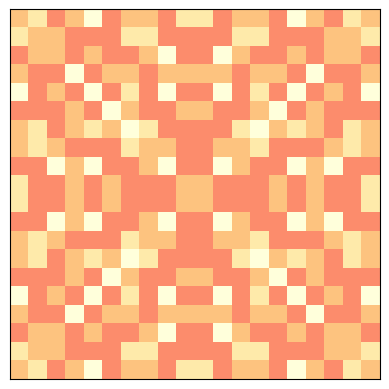

In [11]:
pile.draw()

Notice that it has the repeating elements that are characteristic of fractals. We'll come back to that soon.

Now let's look at an animation, starting from this initialized pile. Each step of the animation drops a single grain at a random location and runs until no more cells topple.

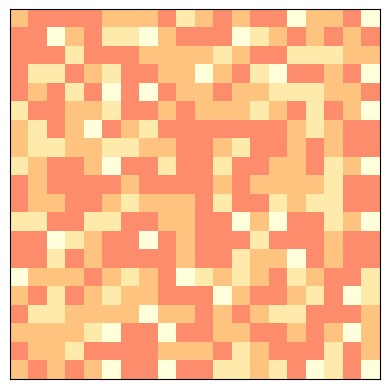

In [12]:
pile.animate(frames=100, step=pile.drop_and_run)

After a while, the pile looks pretty random.

Here's a plot of the number of cells toppled after each `step`.  

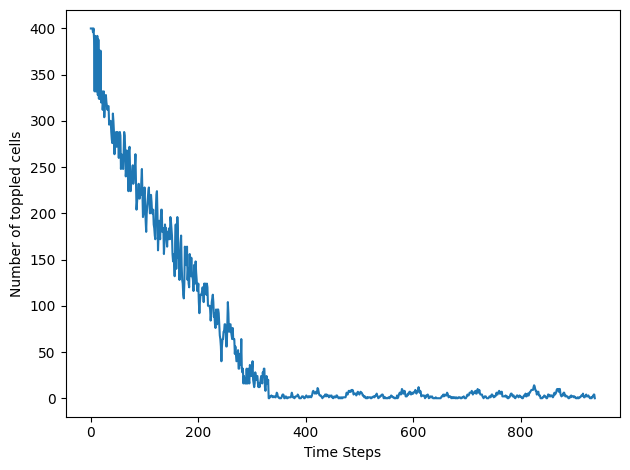

In [13]:
plt.plot(pile.toppled_seq)
decorate(xlabel='Time Steps', ylabel='Number of toppled cells')

The following figure shows the sand pile in its initial state (left), after dropping 20 grains onto random cells (middle), and after 220 drops (right), each time running until the pile reaches equilibrium.

(332, np.int64(53336))
Saving figure to file figs/chap08-1


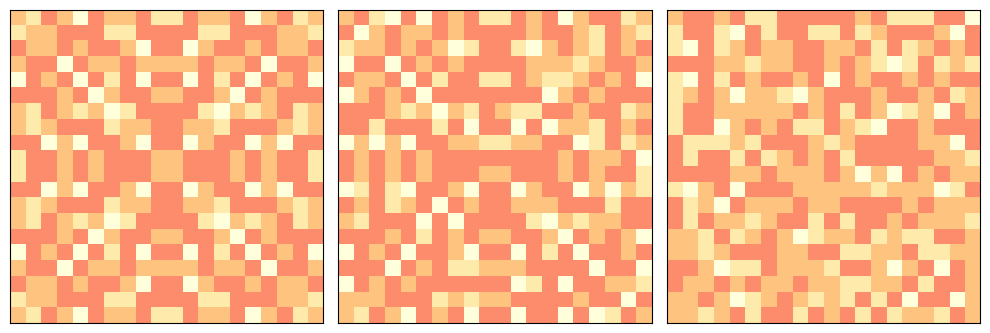

In [14]:
np.random.seed(17)

pile = SandPile(n=20, level=10)
print(pile.run())

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
pile.draw()

plt.subplot(1, 3, 2)
for i in range(20):
    pile.drop_and_run()
pile.draw()

plt.subplot(1, 3, 3)
for i in range(200):
    pile.drop_and_run()
pile.draw()

plt.tight_layout()
savefig('figs/chap08-1')

After 20 drops, the symmetry of the initial configuration has been broken. After 220 drops, the configuration looks random. In fact, the pile is now in a steady state where its statistical properties don't change over time. I'll explain some of those statistical properties in the next section.

## Heavy-tailed distributions

If the sand pile model is in a critical state, we expect to find heavy-tailed distributions for quantities like the duration and size of avalanches. So let's take a look.

I'll make a larger sand pile, with `n=50` and an initial level of `30`, and run until equilibrium:

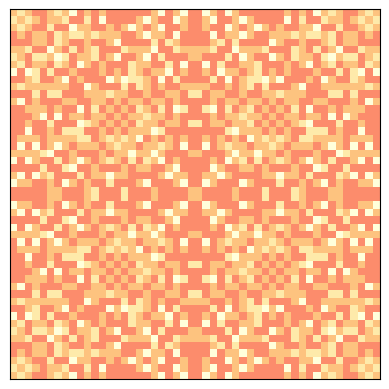

In [15]:
pile2 = SandPile(n=50, level=30)
pile2.run()
pile2.draw()

Next, I'll run 100,000 random drops.

In [16]:
np.random.seed(17)

iters = 100000
%time res = [pile2.drop_and_run() for _ in range(iters)]

CPU times: user 2min 34s, sys: 92.8 ms, total: 2min 34s
Wall time: 2min 34s


`res` is a list of `(T, S)` tuples, where `T` is duration, in time steps, and `S` is cells toppled. We can use `np.transpose` to unpack `res` into two NumPy arrays:

In [17]:
T, S = np.transpose(res)

A large majority of drops have duration 1 and no toppled cells; if we filter them out before plotting, we get a clearer view of the rest of the distribution.

In [18]:
T = T[T>1]
S = S[S>0]

The distributions of `T` and `S` have many small values and a few very large ones. I'll use the `Pmf` class from `empiricaldist` to make a PMF of the values, that is, a map from each value to its probability of occurring (see Chapter 4).

In [19]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [20]:
from empiricaldist import Pmf

pmfT = Pmf.from_seq(T)
pmfS = Pmf.from_seq(S)

The following figure shows the distribution of avalanche duration (left) and size (right) on a linear scale, for values less than 50.

Saving figure to file figs/chap08-2


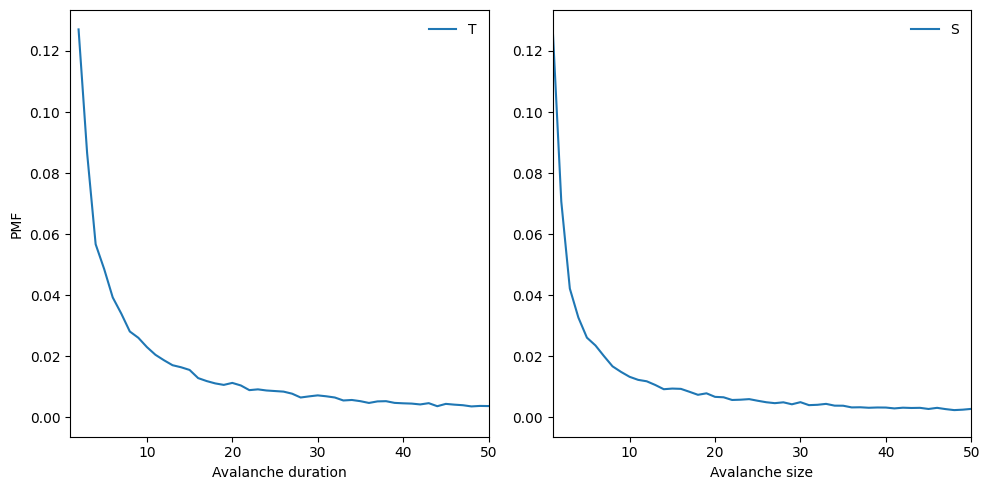

In [21]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)

pmfT.plot(label='T')
decorate(xlabel='Avalanche duration',
                 ylabel='PMF',
                 xlim=[1, 50], loc='upper right')

plt.subplot(1, 2, 2)
pmfS.plot(label='S')
decorate(xlabel='Avalanche size',
                 xlim=[1, 50])

savefig('figs/chap08-2')

As we saw in Chapter 4, we can get a clearer picture of these distributions by plotting them on a log-log scale, as shown in the following figure.

[-1.1188474]


[-1.01439469]


Saving figure to file figs/chap08-3


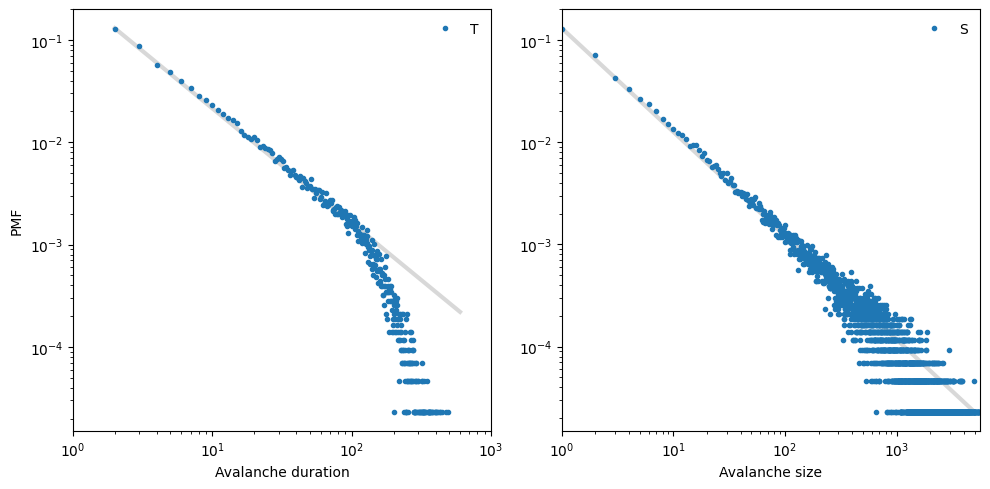

In [22]:
def slope(xs, ys):
    return np.diff(np.log(ys)) / np.diff(np.log(xs))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)

xs = [2, 600]
ys = [1.3e-1, 2.2e-4]
print(slope(xs, ys))

options = dict(lw=3, color='gray', alpha=0.3)
plt.plot(xs, ys, **options)

pmfT.plot(lw=0, marker='.', label='T')
decorate(xlabel='Avalanche duration',
                 xlim=[1, 1000],
                 ylabel='PMF',
                 xscale='log',
                 yscale='log',
                 loc='upper right')

plt.subplot(1, 2, 2)

xs = [1, 5000]
ys = [1.3e-1, 2.3e-5]
print(slope(xs, ys))

plt.plot(xs, ys, **options)
pmfS.plot(lw=0, marker='.', label='S')
decorate(xlabel='Avalanche size',
                 xlim=[1, 5600],
                 xscale='log',
                 yscale='log')

savefig('figs/chap08-3')

For values between 1 and 100, the distributions are nearly straight on a log-log scale, which is characteristic of a heavy tail. The gray lines in the figure have slopes near -1, which suggests that these distributions follow a power law with parameters near $\alpha=1$.

For values greater than 100, the distributions fall away more quickly than the power law model, which means there are fewer very large values than the model predicts. One possibility is that this effect is due to the finite size of the sand pile; if so, we might expect larger piles to fit the power law better.

Another possibility, which you can explore in one of the exercises at the end of this chapter, is that these distributions do not strictly obey a power law. But even if they are not power-law distributions, they might still be heavy-tailed.

**Exercise:** Try running the model longer to see if you can get a less noisy plot of the distributions of `T` and `S`.

## Fractals

Another property of critical systems is fractal geometry. The initial configuration in the first figure of this chapter (left) resembles a fractal, but you can't always tell by looking. A more reliable way to identify a fractal is to estimate its fractal dimension, as we saw in Chapter 7.

I'll start by making a bigger sand pile, with `n=131` and initial level `22`.

In [23]:
pile3 = SandPile(n=131, level=22)
%time pile3.run()

CPU times: user 19.2 s, sys: 4 ms, total: 19.2 s
Wall time: 19.2 s


(28379, np.int64(211320220))

It takes 28,379 steps for this pile to reach equilibrium, with more than 200 million cells toppled.

The initial state sure looks like a fractal.

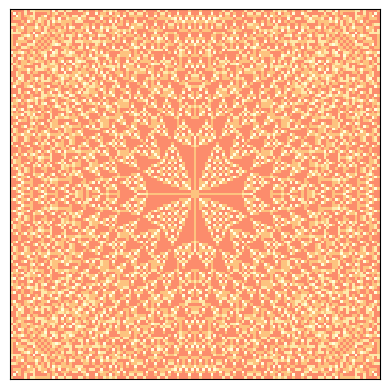

In [24]:
pile3.draw()

To see the resulting pattern more clearly, I select cells with levels 0, 1, 2, and 3, and plot them separately:

In [25]:
def draw_four(pile, levels=range(4)):
    plt.figure(figsize=(8, 8))
    for i, level in enumerate(levels):
        plt.subplot(2, 2, i+1)
        draw_array(pile.array==level, cmap='YlOrRd', vmax=1)
    
    plt.tight_layout()

`draw_four` takes a `SandPile` object. The parameter `levels` is the list of levels we want to plot; the default is the range 0 through 3. If the sand pile has run until equilibrium, these are the only levels that should exist.

Inside the loop, it uses `pile.array==level` to make a boolean array that's `True` where the array is `level` and `False` otherwise. `draw_array` treats these booleans as 1s and 0s.

The following figure shows the results for `pile3`, selecting cells with levels 0, 1, 2, and 3, left to right, top to bottom.

Saving figure to file figs/chap08-4


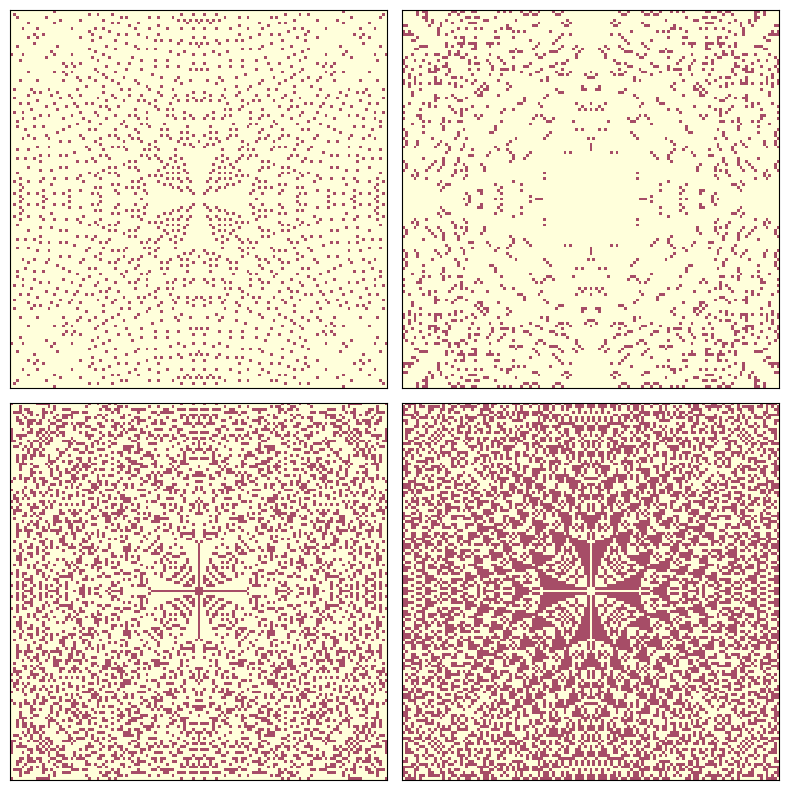

In [26]:
draw_four(pile3)
savefig('figs/chap08-4')

Visually, these patterns resemble fractals, but looks can be deceiving. To be more confident, we can estimate the fractal dimension for each pattern using **box-counting**, as we saw in Chapter 7.

We'll count the number of cells in a small box at the center of the pile, then see how the number of cells increases as the box gets bigger. Here's my implementation:

In [27]:
def count_cells(a):
    """Counts the number of cells in boxes with increasing size.
    
    a: NumPy array
    
    returns: array with three rows: i, i**2, and cell count
    """
    n, m = a.shape
    end = min(n, m)
    
    res = []
    for i in range(1, end, 2):
        top = (n-i) // 2
        left = (m-i) // 2
        box = a[top:top+i, left:left+i]
        total = np.sum(box)
        res.append((i, i**2, total))
        
    return np.transpose(res)

The parameter, `a`, is a boolean array. The size of the box is initially 1. Each time through the loop, it increases by 2 until it reaches `end`, which is the smaller of `n` and `m`.

Each time through the loop, `box` is a set of cells with width and height `i`, centered in the array. `total` is the number of "on" cells in the box.

The result is a list of tuples, where each tuple contains `i`, `i**2`, and the number of cells in the box. When we pass this result to `transpose`, NumPy converts it to an array with three columns, and then **transposes** it; that is, it makes the columns into rows and the rows into columns. The result is an array with 3 rows: `i`, `i**2`, and `total`.

Here's how we use `count_cells`. `box_count` takes a pile and a level, extracts the cells that have the given level, calls `count_cells`, and estimates the fractal dimension.

In [28]:
from scipy.stats import linregress

def box_count(pile, level, plot=False):
    """Estimates the fractal dimension by box counting.
    
    pile: SandPile
    level: which level from the pile to count
    plot: boolean, whether to generate a plot
    
    returns: estimated fractal dimension
    """
    res = count_cells(pile.array==level)
    steps, steps2, cells = res
    
    # select the range where we have a nonzero number of cells
    legit = np.nonzero(cells)
    steps = steps[legit]
    steps2 = steps2[legit]
    cells = cells[legit]

    if plot:
        # only put labels on the left and bottom subplots
        xlabel = 'Box Size' if level in [2, 3] else ''
        ylabel = 'Cell Count' if level in [0, 2] else ''
    
        options = dict(linestyle='dashed', color='gray', alpha=0.7)
        plt.plot(steps, steps2, **options)
        plt.plot(steps, cells, label='level=%d' % level)
        plt.plot(steps, steps, **options)

        decorate(xscale='log', yscale='log',
                         xlim=[1, 200], loc='upper left',
                         xlabel=xlabel, ylabel=ylabel)
        #thinkplot.bigger_text()

    params = linregress(np.log(steps), np.log(cells))
    return params[0]

The first line creates a boolean array that contains `True` where the array equals `level`, calls `count_cells`, and gets an array with three rows. The second line unpacks the rows and assigns them to `steps`, `steps2`, and `cells`.

If `plot` is `True`, it plots `cells` versus `steps` on a log-log scale, along with dashed lines with slopes 1 and 2.

To estimate the slopes of these lines, we can use the SciPy function `linregress`, which fits a line to the data by linear regression (see <https://thinkcomplex.com/regress>).

Finally `box_count_four` applies the box counting algorithm for each value in the sand pile.

In [29]:
def box_count_four(pile, levels=range(4)):
    """Applies box counting to each level in the pile.
    
    pile: SandPile
    levels: list of levels to check
    """
    plt.figure(figsize=(8, 8))

    dims = []
    for i, level in enumerate(levels):
        plt.subplot(2, 2, i+1)
        dim = box_count(pile, level, plot=True)
        dims.append(dim)
        
    return dims

The following figure shows box counts for cells with levels 0, 1, 2, and 3, compared to dashed lines with slopes 1 and 2.

Saving figure to file figs/chap08-5


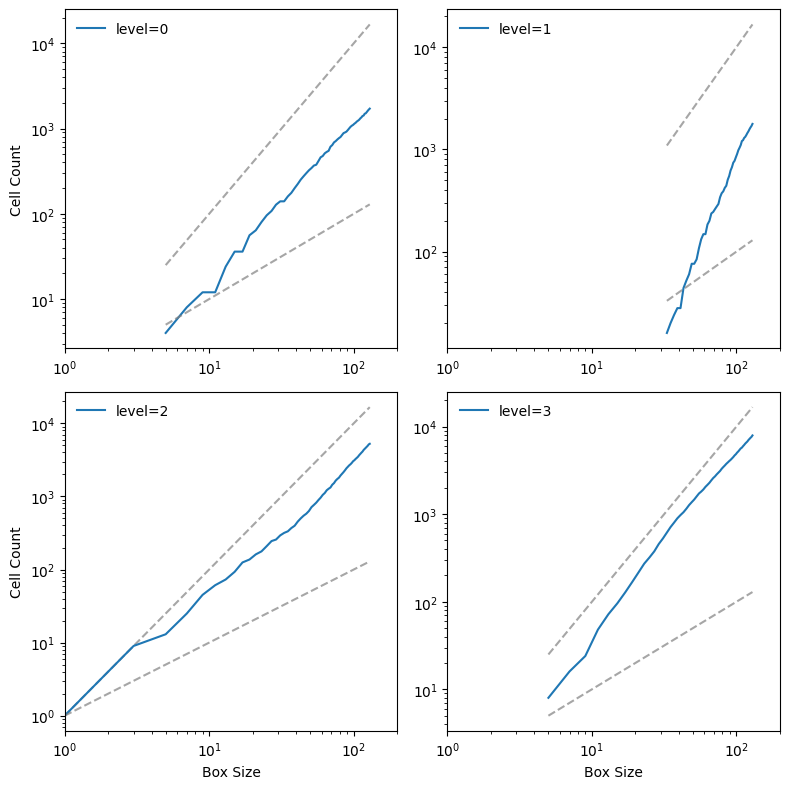

In [30]:
dims = box_count_four(pile3)
savefig('figs/chap08-5')

On a log-log scale, the cell counts form nearly straight lines, which indicates that we are measuring fractal dimension over a valid range of box sizes.

The estimated fractal dimensions are:

In [31]:
for i, dim in enumerate(dims):
    print('%d  %0.3f' % (i, dim))

0  1.871
1  3.502
2  1.781
3  2.084


The fractal dimension for levels 0, 1, and 2 seems to be clearly non-integer, which indicates that the image is fractal.

The estimate for level 3 is indistinguishable from 2, but given the results for the other values, the apparent curvature of the line, and the appearance of the pattern, it seems likely that it is also fractal.

**Exercise:**  Choose a different value of `n` and/or the initial `level` and run this analysis again.  Are the estimated fractal dimensions consistent?

## Pink noise

The title of the original paper that presented the sand pile model is "Self-Organized Criticality: An Explanation of $1/f$ Noise". You can read it at <https://thinkcomplex.com/bak>.

As the subtitle suggests, Bak, Tang and Wiesenfeld were trying to explain why many natural and engineered systems exhibit $1/f$ noise, which is also known as "flicker noise" and "pink noise".

To understand pink noise, we have to take a detour to understand signals, power spectrums, and noise.

**Signal:** A **signal** is any quantity that varies in time. One example is sound, which is variation in air density. In the sand pile model, the signals we'll consider are avalanche durations and sizes as they vary over time.

**Power spectrum:** Any signal can be decomposed into a set of frequency components with different levels of **power**, which is related to amplitude or volume. The **power spectrum** of a signal is a function that shows the power of each frequency component.

**Noise:** In common use, **noise** is usually an unwanted sound, but in the context of signal processing, it is a signal that contains many frequency components.

There are many kinds of noise. For example, "white noise" is a signal that has components with equal power over a wide range of frequencies.

Other kinds of noise have different relationships between frequency and power. In "red noise", the power at frequency $f$ is $1/f^2$, which we can write like this: $$P(f) = 1/f^2$$ We can generalize this equation by replacing the exponent $2$ with a parameter $\beta$: $$P(f) = 1/f^\beta$$ When $\beta=0$, this equation describes white noise; when $\beta=2$ it describes red noise. When the parameter is near 1, the result is called $1/f$ noise. More generally, noise with any value between 0 and 2 is called "pink", because it's between white and red.

We can use this relationship to derive a test for pink noise. Taking the log of both sides yields $$\log P(f) = -\beta \log f$$ So if we plot $P(f)$ versus $f$ on a log-log scale, we expect a straight line with slope $-\beta$.

What does this have to do with the sand pile model? Suppose that every time a cell topples, it makes a sound. If we record a sand pile model while it's running, what would it sound like? In the next section, we'll simulate the sound of the sand pile model and see if it is pink noise.

## The sound of sand

As my implementation of `SandPile` runs, it records the number of cells that topple during each time step, accumulating the results in a list called `toppled_seq`. After running the model in the "Heavy-tailed distributions" section, we can extract the resulting signal:

In [32]:
signal = pile2.toppled_seq
len(signal)

1429764

To compute the power spectrum of this signal we can use the SciPy function `welch`:

In [33]:
from scipy.signal import welch

nperseg = 2048
freqs, powers = welch(np.asarray(signal), nperseg=nperseg, fs=nperseg)

This function uses Welch's method, which splits the signal into segments and computes the power spectrum of each segment. The result is typically noisy, so Welch's method averages across segments to estimate the average power at each frequency. For more about Welch's method, see <https://thinkcomplex.com/welch>.

The parameter `nperseg` specifies the number of time steps per segment. With longer segments, we can estimate the power for more frequencies. With shorter segments, we get better estimates for each frequency. The value I chose, 2048, balances these tradeoffs.

The parameter `fs` is the "sampling frequency", which is the number of data points in the signal per unit of time. By setting `fs=nperseg`, we get a range of frequencies from 0 to `nperseg/2`. This range is convenient, but because the units of time in the model are arbitrary, it doesn't mean much.

The return values, `freqs` and `powers`, are NumPy arrays containing the frequencies of the components and their corresponding powers, which we can plot. The following figure shows the power spectrum of the number of toppled cells over time, on a log-log scale.

Saving figure to file figs/chap08-6


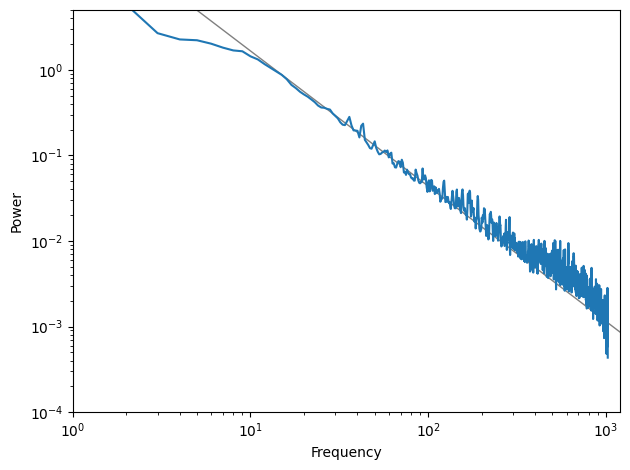

In [34]:
x = nperseg
ys = np.array([x**1.58, 1]) / 2.7e3
plt.plot([1, x], ys, color='gray', linewidth=1)

plt.plot(freqs, powers)
decorate(xlabel='Frequency',
         xscale='log', 
         xlim=[1, 1200],
         ylabel='Power', 
         yscale='log', 
         ylim=[1e-4, 5])

savefig('figs/chap08-6')

For frequencies between 10 and 1000 (in arbitrary units), the spectrum falls on a straight line, which is what we expect for pink or red noise.

The gray line in the figure has slope $-1.58$, which indicates that $$\log P(f) \sim -\beta \log f$$ with parameter $\beta=1.58$, which is the same parameter reported by Bak, Tang, and Wiesenfeld. This result confirms that the sand pile model generates pink noise.

**Exercise:**  Choose a different value of `nperseg` and run this analysis again.  What are the pros and cons of larger segment lengths?  Modify the code to run the model longer and see if you can get a less noisy estimate of the spectrum.

## Reductionism and Holism

The original paper by Bak, Tang and Wiesenfeld is one of the most frequently-cited papers in the last few decades. Some subsequent papers have reported other systems that are apparently self-organized critical (SOC). Others have studied the sand pile model in more detail.

As it turns out, the sand pile model is not a good model of a sand pile. Sand is dense and not very sticky, so momentum has a non-negligible effect on the behavior of avalanches. As a result, there are fewer very large and very small avalanches than the model predicts, and the distribution might not be heavy-tailed.

Bak has suggested that this observation misses the point. The sand pile model is not meant to be a realistic model of a sand pile; it is meant to be a simple example of a broad category of models.

To understand this point, it is useful to think about two kinds of models, **reductionist** and **holistic**. A reductionist model describes a system by describing its parts and their interactions. When a reductionist model is used as an explanation, it depends on an analogy between the components of the model and the components of the system.

For example, to explain why the ideal gas law holds, we can model the molecules that make up a gas with point masses and model their interactions as elastic collisions. If you simulate or analyze this model, you find that it obeys the ideal gas law. This model is satisfactory to the degree that molecules in a gas behave like molecules in the model. The analogy is between the parts of the system and the parts of the model.

Holistic models are more focused on similarities between systems and less interested in analogous parts. A holistic approach to modeling consists of these steps:

-   Observe a behavior that appears in a variety of systems.

-   Find a simple model that demonstrates that behavior.

-   Identify the elements of the model that are necessary and sufficient to produce the behavior.

For example, in *The Selfish Gene*, Richard Dawkins suggests that genetic evolution is just one example of an evolutionary system. He identifies the essential elements of the category — discrete replicators, variability, and differential reproduction — and proposes that any system with these elements will show evidence of evolution.

As another example of an evolutionary system, he proposes "memes", which are thoughts or behaviors that are replicated by transmission from person to person. (This use of "meme" is original to Dawkins, and predates the distantly-related use of the word on the Internet by about 20 years.) As memes compete for the resource of human attention, they evolve in ways that are similar to genetic evolution.

Critics of the meme model have pointed out that memes are a poor analogy for genes; they differ from genes in many obvious ways. Dawkins has argued that these differences are beside the point because memes are not *supposed* to be analogous to genes. Rather, memes and genes are examples of the same category: evolutionary systems. The differences between them emphasize the real point, which is that evolution is a general model that applies to many seemingly disparate systems. The logical structure of this argument is shown in the following figure.

![The logical structure of a holistic model.](https://github.com/AllenDowney/ThinkComplexity/raw/v3/images/model2.png)

Bak has made a similar argument that self-organized criticality is a general model for a broad category of systems:

> Since these phenomena appear everywhere, they cannot depend on any specific detail whatsoever... If the physics of a large class of problems is the same, this gives \[the theorist] the option of selecting the *simplest* possible \[model] belonging to that class for detailed study.

(Bak, *How Nature Works*, Springer-Verlag 1996, page 43.)

Many natural systems demonstrate behaviors characteristic of critical systems. Bak's explanation for this prevalence is that these systems are examples of the broad category of self-organized criticality. There are two ways to support this argument. One is to build a realistic model of a particular system and show that the model exhibits SOC. The second is to show that SOC is a feature of many diverse models, and to identify the essential characteristics those models have in common.

The first approach, which I characterize as reductionist, can explain the behavior of a particular system. The second approach, which I am calling holistic, can explain the prevalence of criticality in natural systems. They are different models with different purposes.

For reductionist models, realism is the primary virtue, and simplicity is secondary. For holistic models, it is the other way around.

## SOC, causation, and prediction

If a stock market index drops by a fraction of a percent in a day, there is no need for an explanation. But if it drops 10%, people want to know why. Pundits on television are willing to offer explanations, but the real answer may be that there is no explanation.

Day-to-day variability in the stock market shows evidence of criticality: the distribution of value changes is heavy-tailed and the time series exhibits pink noise. If the stock market is a critical system, we should expect occasional large changes as part of the ordinary behavior of the market.

The distribution of earthquake sizes is also heavy-tailed, and there are simple models of the dynamics of geological faults that might explain this behavior. If these models are right, they imply that large earthquakes are not exceptional; that is, they do not require explanation any more than small earthquakes do.

Similarly, Charles Perrow has suggested that failures in large engineered systems, like nuclear power plants, are like avalanches in the sand pile model. Most failures are small, isolated, and harmless, but occasionally a coincidence of bad fortune yields a catastrophe. When big accidents occur, investigators go looking for the cause, but if Perrow's "normal accident theory" is correct, there may be no special cause of large failures.

These conclusions are not comforting. Among other things, they imply that large earthquakes and some kinds of accidents are fundamentally unpredictable. It is impossible to look at the state of a critical system and say whether a large avalanche is "due". If the system is in a critical state, then a large avalanche is always possible. It just depends on the next grain of sand.

In a sand pile model, what is the cause of a large avalanche? Philosophers sometimes distinguish the **proximate** cause, which is most immediately responsible, from the **ultimate** cause, which is considered some deeper kind of explanation (see <https://thinkcomplex.com/cause>).

In the sand pile model, the proximate cause of an avalanche is a grain of sand, but the grain that causes a large avalanche is identical to every other grain, so it offers no special explanation. The ultimate cause of a large avalanche is the structure and dynamics of the system as a whole: large avalanches occur because they are a property of the system.

Many social phenomena, including wars, revolutions, epidemics, inventions, and terrorist attacks, are characterized by heavy-tailed distributions. If these distributions are prevalent because social systems are SOC, major historical events may be fundamentally unpredictable and unexplainable.

## Exercises

**Exercise:** To test whether the distributions of `T` and `S` are heavy-tailed, we plotted their `Pmf` on a log-log scale, which is what Bak, Tang, and Wiesenfeld show in their paper.  But as we saw in Chapter 4, this visualization can obscure the shape of the distribution.  Using the same data, make a plot that shows the CDFs of `S` and `T`.  What can you say about the shape of these distributions?  Do they follow a power law?  Are they heavy tailed?

You might find it helpful to plot the CDFs on a log-x scale and the complementary CDFs on a log-log scale.

In [35]:
# Solution

from empiricaldist import Cdf

cdf = Cdf.from_seq(S)

In [36]:
# Solution

# Here is the CDF of `S` on a log-x scale (left) and on a log-log scale (right).

def plot_cdf(series, label, xlabel):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)

    cdf = Cdf.from_seq(series)
    cdf.step(label=label)
    decorate(xlabel=xlabel,
             ylabel='Cdf',
             xscale='log')

    plt.subplot(1, 2, 2)

    (1-cdf).plot(label=label)
    decorate(xlabel=xlabel,
             xscale='log',
             yscale='log')

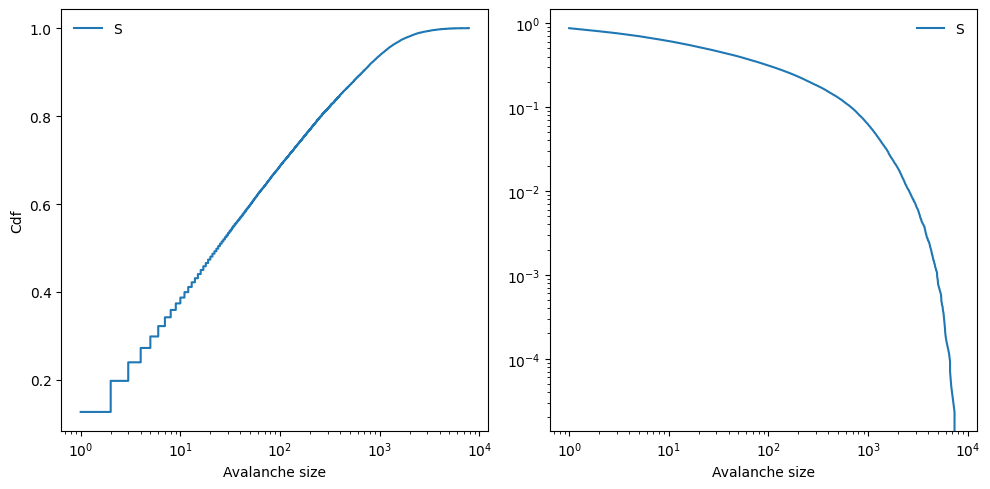

In [37]:
# Solution

plot_cdf(S, 'S', xlabel='Avalanche size')

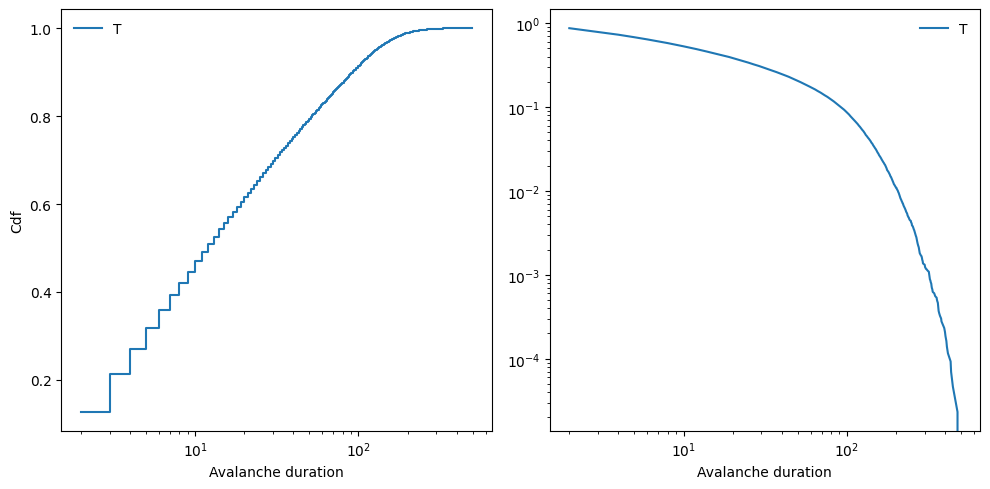

In [38]:
# Solution

# And here are the results for `T`.

plot_cdf(T, 'T', xlabel='Avalanche duration')

In [39]:
# Solution

# On a log-log scale, these CDFs are not straight, 
# which indicates that they do not follow a power law.

# However, on a log-x scale, they resemble lognormal distributions
# (with the left tail truncated).  The lognormal distribution is
# also considered heavy-tailed.

# In my opinion, many papers in complexity science are too quick to 
# identify power laws based on plots showing histograms or probability 
# mass functions (PMFs).  I think many of these distributions, 
# including both measurements from the world and results from simulations,
# are better modeled by other heavy-tailed distributions.

# However, the argument the sand pile model is intended to make is valid 
# either way: we observe that heavy-tailed distributions are common in 
# natural systems, and SOC is a possible explanation, regardless of whether
# the distributions are specifically power law distributions or more generally 
# heavy-tailed.

**Exercise:** In the "Fractals" section we showed that the initial equilibrium of the sand pile model produces fractal patterns.  But after we drop a large number of random grains, the patterns look more random.

Starting with the example in the "Fractals" section, run the sand pile model for a while and then compute fractal dimensions for each of the 4 levels.  Is the sand pile model fractal in steady state?

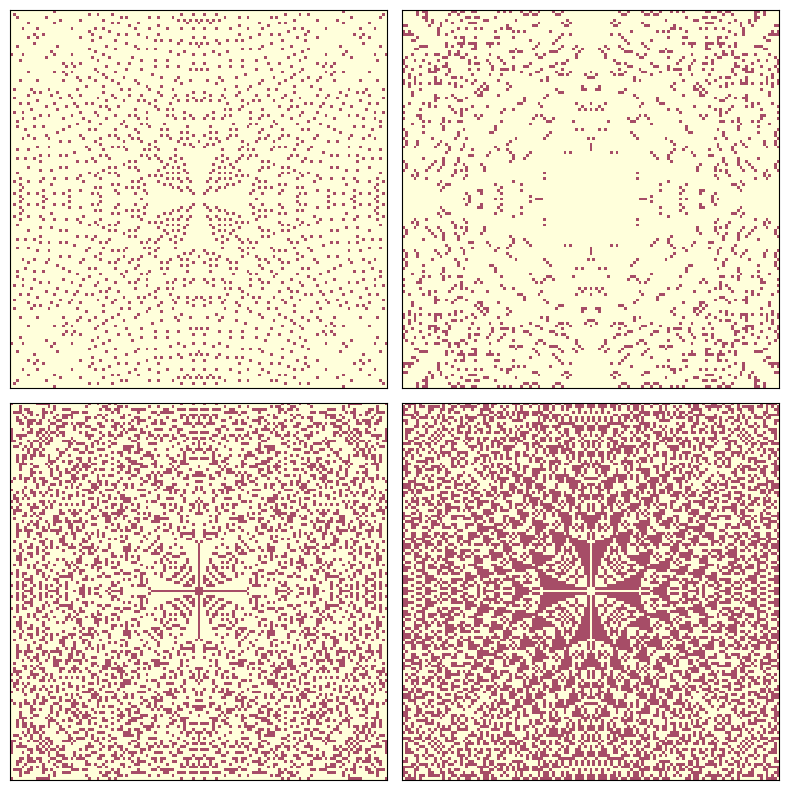

In [40]:
# Solution

pile4 = SandPile(n=131, level=22)
pile4.run()
draw_four(pile4)

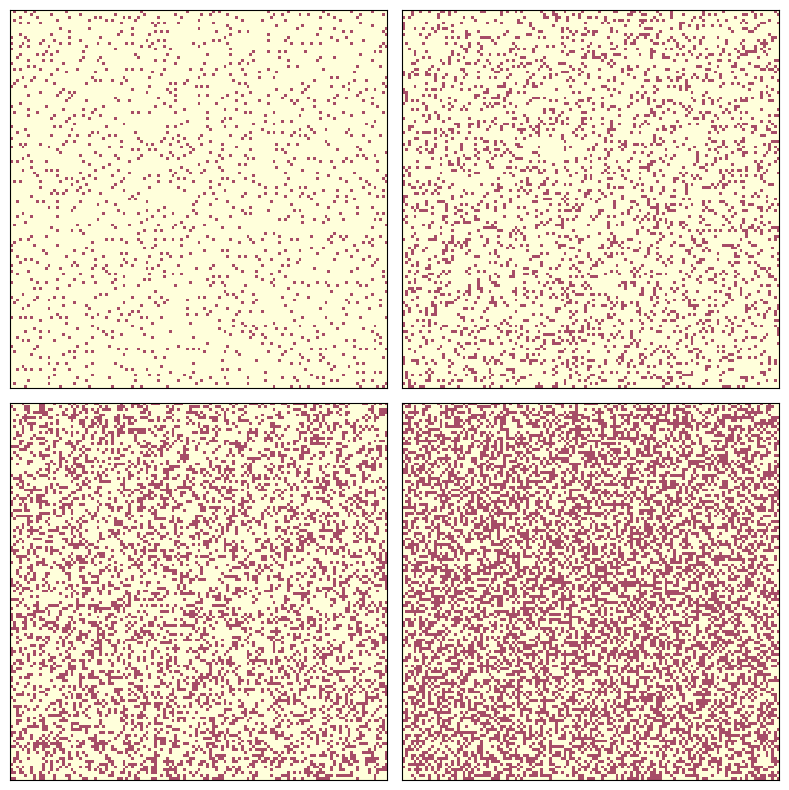

In [41]:
# Solution

# After it runs for a while, it looks pretty random.
# But we have to be careful; people are not very good at judging 
# what is random or not.

for i in range(10000):
    pile4.drop_and_run()
    
draw_four(pile4)

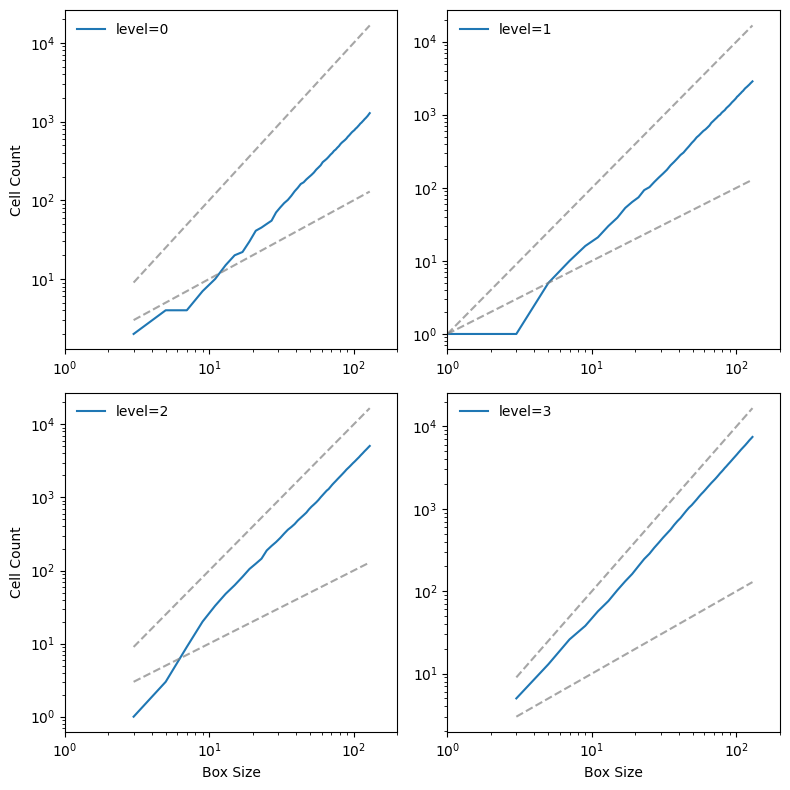

In [42]:
# Solution

# Here are the results from the box counting algorithm.
# The lines are reasonably straight, which means our
# estimates of the fractal dimension are valid.

dims = box_count_four(pile4)

In [43]:
# Solution

# And here are the fractal dimensions.

for i, dim in enumerate(dims):
    print('%d  %0.3f' % (i, dim))

0  1.868
1  1.892
2  2.151
3  1.966


In [44]:
# Solution

# They all seem to be converging on 2, which is what we expect
# from a totally random pattern.  It's hard to say for sure, 
# because it's possible that they are still fractal with dimensions 
# close to 2, but not exactly 2.  But I think that's unlikely.

# I think this observation undermines the SOC argument to some degree.
# If the sand pile model is not fractal in steady state, it does not 
# explain the prevalence of fractal geometry in natural systems.

**Exercise:** Another version of the sand pile model, called the "single source" model, starts from a different initial condition: instead of all cells at the same level, all cells are set to 0 except the center cell, which is set to a very large value.

Write a function that creates a `SandPile` object, sets up the single source initial condition, and runs until the pile reaches equilibrium.  Does the result appear to be fractal?

You can read more about this version of the sand pile model at <https://thinkcomplex.com/sand>.

In [45]:
# Solution

# The following function clears all cells and puts a tower in the center.
    
def single_source(pile, height=1024):
    """Adds a tower to the center cell.
    
    height: value assigned to the center cell
    """
    a = pile.array
    n, m = a.shape
    a[:, :] = 0
    a[n//2, m//2] = height

In [46]:
# Solution

# `run_ss_pile` builds a single-source sand pile and runs until equilibrium.

def run_ss_pile(n, k=10):
    """Runs a single source model.
    
    k: integer power of two of height
    """
    pile = SandPile(n)
    single_source(pile, 2**k)
    print(pile.run())        
    return pile

(14244, np.int64(4900462))


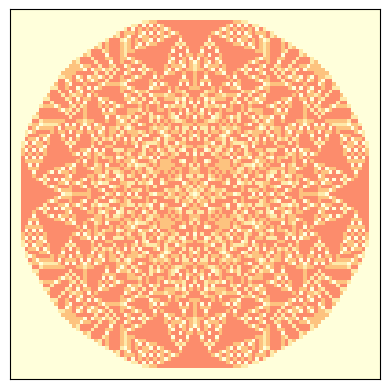

In [47]:
# Solution

# Let's try it with `2**14` grains:

pile5 = run_ss_pile(n=101, k=14)
pile5.draw()

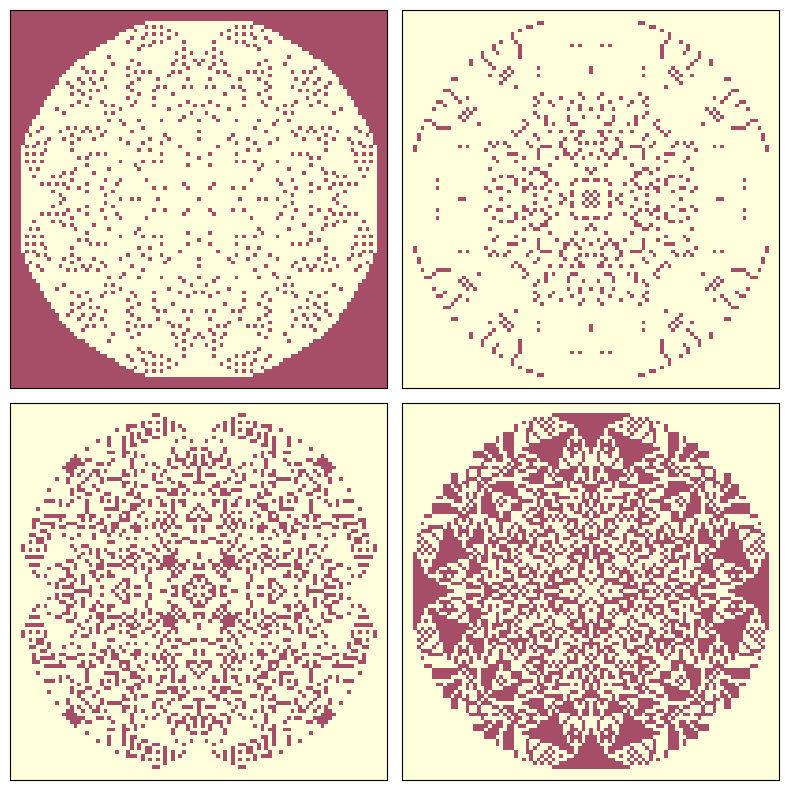

In [48]:
# Solution

# Visually, the results sure look fractal.

draw_four(pile5)

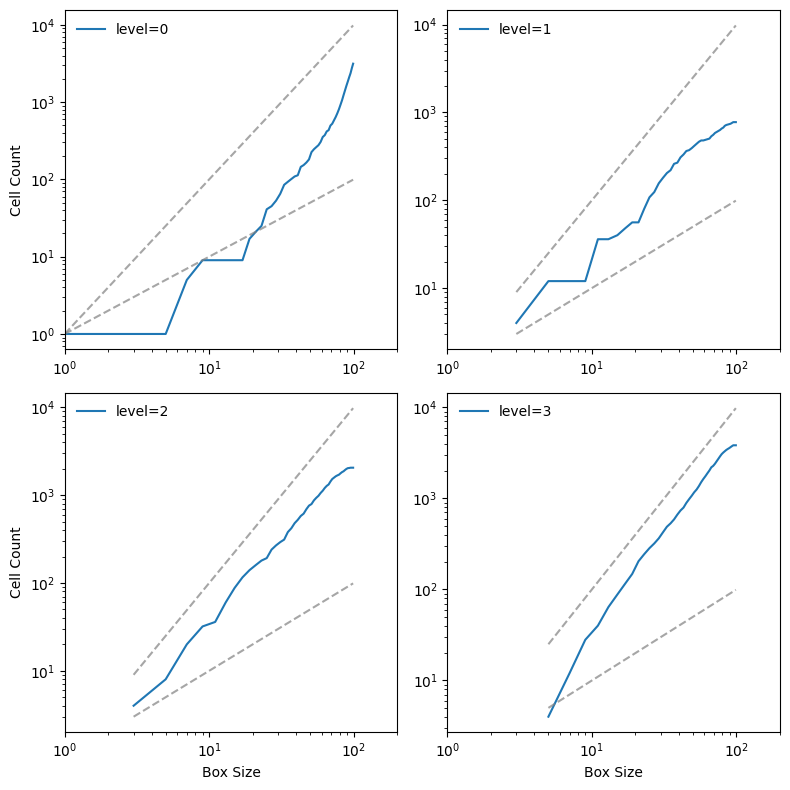

In [49]:
# Solution

# And here are the results from the box counting algorithm.

# For value 0, the line gets steeper at the end because of the boundary cells.

# For the other values, it drops off at the end.

# So the estimated dimensions might not be very accurate.
# A better alternative would be a radial version of the box counting algorithm.

dims = box_count_four(pile5)

In [50]:
# Solution

# The results are not as clear as we might like, 
# but at least some of these patterns seem to have non-integer dimensions.

for i, dim in enumerate(dims):
    print('%d  %0.3f' % (i, dim))

0  2.094
1  1.598
2  1.848
3  2.185


**Exercise:** In their 1989 paper, Bak, Chen and Creutz suggest that the Game of Life is a self-organized critical system (see <https://thinkcomplex.com/bak89>).

To replicate their tests, start with a random configuration and run the GoL CA until it stabilizes. Then choose a random cell and flip it. Run the CA until it stabilizes again, keeping track of `T`, the number of time steps it takes, and `S`, the number of cells affected. Repeat for a large number of trials and plot the distributions of `T` and `S`. Also, estimate the power spectrums of `T` and `S` as signals in time, and see if they are consistent with pink noise.

**Exercise:** In *The Fractal Geometry of Nature*, Benoit Mandelbrot proposes what he calls a "heretical" explanation for the prevalence of heavy-tailed distributions in natural systems. It may not be, as Bak suggests, that many systems can generate this behavior in isolation. Instead there may be only a few, but interactions between systems might cause the behavior to propagate.

To support this argument, Mandelbrot points out:

-   The distribution of observed data is often "the joint effect of a fixed underlying *true distribution* and a highly variable *filter*".

-   Heavy-tailed distributions are robust to filtering; that is, "a wide variety of filters leave their asymptotic behavior unchanged".

What do you think of this argument? Would you characterize it as reductionist or holist?

**Exercise:** Read about the "Great Man" theory of history at <https://thinkcomplex.com/great>. What implication does self-organized criticality have for this theory?

[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)